# Inference — рисунок → психологический портрет

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install -q ultralytics dill iterative-stratification
import torch
print(torch.__version__, torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.9 MB/s eta 0:00:00
2.10.0+cu128 True


In [5]:
import os, csv, json, math, time, re
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np

DRIVE = Path('/content/drive/MyDrive/vkr')
IMAGES_DIR = DRIVE / 'crops'
REPORT_CSV = DRIVE / 'report.csv'
RESULTS_CSV = DRIVE / 'results.csv'
CROP_META = DRIVE / 'crop_meta.csv'
MODEL_PATH = DRIVE / 'model_seed42.pth'
CRIT_JSON = DRIVE / 'criteria_interpretations.json'

IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

for p in [IMAGES_DIR, REPORT_CSV, RESULTS_CSV, MODEL_PATH, CRIT_JSON]:
    print(p, p.exists())

/content/drive/MyDrive/vkr/crops True
/content/drive/MyDrive/vkr/report.csv True
/content/drive/MyDrive/vkr/results.csv True
/content/drive/MyDrive/vkr/model_seed42.pth True
/content/drive/MyDrive/vkr/criteria_interpretations.json True


In [6]:
def parse_report(path):
    with open(path, 'r', encoding='utf-8') as f:
        rows = list(csv.reader(f))
    header_page, header_q, header_opts = rows[0], rows[1], rows[2]
    data_rows = rows[4:]
    col_names = []
    for i, (p, q, o) in enumerate(zip(header_page, header_q, header_opts)):
        parts = [x.strip() for x in [p, q, o] if x.strip()]
        col_names.append(' | '.join(parts) if parts else f'col_{i}')
    records = []
    for row in data_rows:
        if not row or not row[0].strip(): continue
        rec = {col_names[i]: val.strip() for i, val in enumerate(row) if i < len(col_names)}
        records.append(rec)
    return col_names, records

def parse_criteria(path):
    crit = {}
    with open(path, 'r', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            if row['column'] != 'mean':
                crit[row['column']] = {'f1_macro': float(row['f1_macro']),
                    'f1_micro': float(row['f1_micro']), 'f1_weighted': float(row['f1_weighted'])}
    return crit

col_names, records = parse_report(REPORT_CSV)
criteria = parse_criteria(RESULTS_CSV)
code_col = col_names[9]
F1_THRESHOLD = 0.8
TARGET_CRITERIA = {n for n, m in criteria.items() if m['f1_macro'] < F1_THRESHOLD}

with open(REPORT_CSV, 'r', encoding='utf-8') as f:
    raw = list(csv.reader(f))
row0, row1, row2 = raw[0], raw[1], raw[2]

def clean_q(q):
    q = re.sub(r'^\d+[\.\s]*', '', q)
    q = re.sub(r'\s*\([^)]*(?:выбор|ответ)[^)]*\)\s*$', '', q, flags=re.IGNORECASE)
    q = q.replace('\xa0', ' ')
    return re.sub(r'\s+', ' ', q).strip().lower()

cur_q, cur_type = '', ''
col_struct = []
for i in range(len(row1)):
    r1, r2 = row1[i].strip(), row2[i].strip()
    if r1:
        cur_q = r1
        m = re.search(r'\(([^)]*)\)', r1)
        cur_type = m.group(1).lower() if m else ''
    col_struct.append({'idx': i, 'q_clean': clean_q(cur_q), 'option': r2,
        'opt_lower': r2.strip().lower(), 'is_multi': 'множественный' in cur_type})

def parse_suffix(name):
    m = re.search(r'\.(\d+)$', name)
    return (name[:m.start()], int(m.group(1))) if m else (name, 0)

criteria_col_map, unmapped = {}, []
for crit_name in criteria.keys():
    base_name, suffix_num = parse_suffix(crit_name)
    parts = base_name.split(' | ')
    if len(parts) == 2:
        feat, var = parts[0].strip().lower(), parts[1].strip().lower()
        matches = [cs['idx'] for cs in col_struct if cs['opt_lower'] == var and feat in cs['q_clean']]
        if not matches:
            ws = [w for w in feat.split() if len(w) > 2]
            matches = [cs['idx'] for cs in col_struct if cs['opt_lower'] == var and ws and all(w in cs['q_clean'] for w in ws[:2])]
        if matches:
            criteria_col_map[crit_name] = ('binary', matches[suffix_num] if suffix_num < len(matches) else matches[0])
        else:
            unmapped.append(crit_name)
    else:
        feat = parts[0].strip().lower()
        occ = [cs['idx'] for cs in col_struct if not cs['is_multi'] and not cs['option'] and feat == cs['q_clean']]
        if not occ:
            occ = [cs['idx'] for cs in col_struct if not cs['is_multi'] and not cs['option'] and feat in cs['q_clean']]
        if occ:
            criteria_col_map[crit_name] = ('multiclass', occ[suffix_num] if suffix_num < len(occ) else occ[-1])
        else:
            unmapped.append(crit_name)

criteria_configs = []
for name, m in criteria.items():
    if name not in criteria_col_map: continue
    task_type, col_idx = criteria_col_map[name]
    criteria_configs.append({'name': name, 'task_info': {'type': task_type, 'col_idx': col_idx},
        'priority': 'high' if name in TARGET_CRITERIA else 'normal'})
criteria_configs.sort(key=lambda x: x['name'])
print(f'mapped: {len(criteria_configs)}/{len(criteria)}')

mapped: 117/117


In [7]:
def normalize(s):
    return s.strip().replace(' ', '').lower()

available_images = {}
for f in IMAGES_DIR.iterdir():
    if (f.is_file() or f.is_symlink()) and f.suffix.lower() in IMAGE_EXTENSIONS:
        available_images[normalize(f.stem)] = str(f)

records_by_code = defaultdict(list)
for rec in records:
    code = rec.get(code_col, '').strip()
    if not code or normalize(code) not in available_images: continue
    records_by_code[code].append(rec)

def majority_label(values, task_type):
    if task_type == 'binary':
        pos = sum(1 for v in values if v)
        return 1 if pos * 2 >= len(values) and pos > 0 else 0
    non_empty = [v for v in values if str(v).strip()]
    if not non_empty: return ''
    ctr = Counter(non_empty)
    top_cnt = ctr.most_common(1)[0][1]
    top_vals = [v for v, c in ctr.items() if c == top_cnt]
    if len(top_vals) == 1: return top_vals[0]
    for v in non_empty:
        if v in top_vals: return v
    return non_empty[0]

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
dataset_for_enc = []
for code, recs in records_by_code.items():
    labels = {}
    for cfg in criteria_configs:
        n = cfg['name']; ci = cfg['task_info']['col_idx']; col = col_names[ci]
        vals = [r.get(col, '').strip() for r in recs]
        labels[n] = majority_label(vals, cfg['task_info']['type'])
    dataset_for_enc.append({'code': code, 'labels': labels})

binary_names = [c['name'] for c in criteria_configs if c['task_info']['type'] == 'binary']
multi_names  = [c['name'] for c in criteria_configs if c['task_info']['type'] == 'multiclass']



target_names = {c['name'] for c in criteria_configs if c['priority'] == 'high'}
N_enc = len(dataset_for_enc)
rare_cols = []
for bn in binary_names:
    if bn not in target_names: continue
    col = [1 if dataset_for_enc[i]['labels'].get(bn) == 1 else 0 for i in range(N_enc)]
    s = sum(col)
    if 1 < s < N_enc: rare_cols.append(col)
for mn in multi_names:
    if mn not in target_names: continue
    ctr = Counter(dataset_for_enc[i]['labels'].get(mn, '') for i in range(N_enc))
    for cls, cnt in ctr.items():
        if cls and 1 < cnt < N_enc and cnt / N_enc < 0.3:
            rare_cols.append([1 if dataset_for_enc[i]['labels'].get(mn) == cls else 0 for i in range(N_enc)])

if rare_cols:
    Y_e = np.array(rare_cols, dtype=int).T; X_e = np.arange(N_enc).reshape(-1, 1)
    mss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
    train_idx_enc, _ = next(mss1.split(X_e, Y_e))
else:
    rng = np.random.default_rng(42); perm = rng.permutation(N_enc)
    train_idx_enc = perm[:int(N_enc * 0.70)]

train_data_enc = [dataset_for_enc[i] for i in train_idx_enc]

label_encoders = {}
for cfg in criteria_configs:
    if cfg['task_info']['type'] != 'multiclass': continue
    name = cfg['name']
    vals = sorted({str(item['labels'].get(name, '')).strip() for item in train_data_enc
                   if str(item['labels'].get(name, '')).strip()})
    enc = {'': 0}
    for i, v in enumerate(vals, 1): enc[v] = i
    label_encoders[name] = enc

label_decoders = {n: {i: lbl for lbl, i in enc.items()} for n, enc in label_encoders.items()}
print('encoders:', len(label_encoders))

encoders: 23


In [8]:
BBOX_DIM = 12

def stem_key(filename):
    return normalize(Path(filename).stem)

def compute_bbox_feats(x1, y1, x2, y2, W, H, src='yolo'):
    if W <= 0 or H <= 0: return [0.0] * BBOX_DIM
    bw = max(x2 - x1, 1.0); bh = max(y2 - y1, 1.0)
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    rw, rh = bw / W, bh / H
    aspect = bh / bw
    touches_top    = 1.0 if y1 < 0.05 * H else 0.0
    touches_bottom = 1.0 if y2 > 0.95 * H else 0.0
    touches_left   = 1.0 if x1 < 0.05 * W else 0.0
    touches_right  = 1.0 if x2 > 0.95 * W else 0.0
    diag = (W**2 + H**2) ** 0.5
    min_corner = min(((cx - cxx)**2 + (cy - cyy)**2) ** 0.5
                     for cxx in (0, W) for cyy in (0, H)) / diag
    is_yolo = 1.0 if str(src).startswith('yolo') else 0.0
    return [rw, rh, rw * rh, cx / W, cy / H, min(aspect, 5.0),
            touches_top, touches_bottom, touches_left, touches_right,
            min_corner, is_yolo]

bbox_by_code = {}
if CROP_META.exists():
    with open(CROP_META, encoding='utf-8') as f:
        for r in csv.DictReader(f):
            try:
                src = r.get('bbox_source', '')
                if src.startswith('error'): continue
                feats = compute_bbox_feats(float(r['x1']), float(r['y1']),
                    float(r['x2']), float(r['y2']),
                    float(r['orig_w']), float(r['orig_h']), src)
                bbox_by_code[stem_key(r['src_file'])] = feats
            except (KeyError, ValueError): continue
    print('bbox:', len(bbox_by_code))

_train_feats = []
for code in [d['code'] for d in train_data_enc]:
    feats = bbox_by_code.get(normalize(code), [0.0] * BBOX_DIM)
    _train_feats.append(feats)
_train_feats = np.array(_train_feats, dtype=np.float32)
BBOX_MEAN = _train_feats.mean(axis=0)
BBOX_STD  = _train_feats.std(axis=0) + 1e-6
BBOX_MEAN_T = torch.tensor(BBOX_MEAN, dtype=torch.float32)
BBOX_STD_T  = torch.tensor(BBOX_STD, dtype=torch.float32)

bbox: 8175


In [9]:
import torch.nn as nn
import torch.nn.functional as F_t
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 320

def sanitize_column(col):
    return re.sub(r'\W|^(?=\d)', '_', col)

target_cols = [c['name'] for c in criteria_configs]
safe_col_map = {c: sanitize_column(c) for c in target_cols}
num_classes_safe = {}
for cfg in criteria_configs:
    n = cfg['name']; sn = safe_col_map[n]
    if cfg['task_info']['type'] == 'binary':
        num_classes_safe[sn] = 2
    else:
        num_classes_safe[sn] = max(len(label_encoders.get(n, {})), 2)
target_safe_names    = {safe_col_map[c['name']] for c in criteria_configs if c['priority'] == 'high'}
nontarget_safe_names = {safe_col_map[c['name']] for c in criteria_configs if c['priority'] != 'high'}

class TwoStreamModel(nn.Module):
    IMG_FEAT_DIM = 1024 + 2048
    BBOX_FEAT_DIM = 64
    PROJ_DIM = 512
    def __init__(self, num_classes_dict, target_safe_names, nontarget_safe_names,
                 bbox_in_dim=BBOX_DIM, dropout=0.3):
        super().__init__()
        base = models.resnet152(weights=None)
        self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1; self.layer2 = base.layer2
        self.layer3 = base.layer3; self.layer4 = base.layer4


        self.pool = nn.AdaptiveAvgPool2d(1)
        self.bbox_mlp = nn.Sequential(
            nn.Linear(bbox_in_dim, 64), nn.ReLU(inplace=True), nn.Dropout(0.1),
            nn.Linear(64, self.BBOX_FEAT_DIM), nn.ReLU(inplace=True))
        self.target_proj = nn.Sequential(
            nn.Linear(self.IMG_FEAT_DIM + self.BBOX_FEAT_DIM, self.PROJ_DIM),
            nn.ReLU(inplace=True), nn.Dropout(dropout))
        self.nontarget_proj = nn.Sequential(
            nn.Linear(self.IMG_FEAT_DIM + self.BBOX_FEAT_DIM, self.PROJ_DIM),
            nn.ReLU(inplace=True), nn.Dropout(dropout))
        self.target_safe = set(target_safe_names)
        self.nontarget_safe = set(nontarget_safe_names)
        self.heads = nn.ModuleDict({col: nn.Linear(self.PROJ_DIM, n) for col, n in num_classes_dict.items()})
    def forward(self, img, bbox):
        x = self.stem(img); x = self.layer1(x); x = self.layer2(x)
        f3 = self.layer3(x); f4 = self.layer4(f3)
        img_feat = torch.cat([self.pool(f3).flatten(1), self.pool(f4).flatten(1)], dim=1)
        bbox_feat = self.bbox_mlp(bbox)
        feat = torch.cat([img_feat, bbox_feat], dim=1)
        t_feat = self.target_proj(feat); n_feat = self.nontarget_proj(feat)
        return {col: head(t_feat if col in self.target_safe else n_feat)
                for col, head in self.heads.items()}

model = TwoStreamModel(num_classes_safe, target_safe_names, nontarget_safe_names, BBOX_DIM)
state = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state, strict=False)
model.to(DEVICE).eval()
print('heads:', len(model.heads), '| params:', sum(p.numel() for p in model.parameters()) / 1e6, 'M')

heads: 117 | params: 61.519605 M


In [10]:
from ultralytics import YOLO
import cv2

yolo_model = YOLO('yolov8n.pt')
PERSON_CLS = 0
YOLO_CONF = 0.10
PAD_PCT = 0.08
OUT_SIZE = 384

CLAHE_DETECT = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(16, 16))

def enhance_for_detection(pil_img):
    arr = np.array(pil_img.convert('L'))
    arr = cv2.GaussianBlur(arr, (3, 3), 0)
    arr = CLAHE_DETECT.apply(arr)
    return Image.fromarray(cv2.cvtColor(arr, cv2.COLOR_GRAY2RGB))

def yolo_bbox(pil_img):
    arr = np.array(pil_img.convert('RGB'))
    res = yolo_model.predict(arr, conf=YOLO_CONF, classes=[PERSON_CLS], device=DEVICE.type, verbose=False)[0]
    if res.boxes is None or len(res.boxes) == 0: return None
    boxes = res.boxes.xyxy.cpu().numpy()
    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    return tuple(map(float, boxes[areas.argmax()]))

def contour_bbox(pil_img):
    g = np.array(pil_img.convert('L'))
    H, W = g.shape
    mh, mw = int(H * 0.03), int(W * 0.03)
    inner = g[mh:H-mh, mw:W-mw]
    Hi, Wi = inner.shape
    img_area = Hi * Wi
    bw = cv2.adaptiveThreshold(inner, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                               cv2.THRESH_BINARY_INV, 51, 10)
    bw = cv2.medianBlur(bw, 3)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13))
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, k, iterations=1)
    n_lbl, _, stats, _ = cv2.connectedComponentsWithStats(bw, 8)
    if n_lbl <= 1: return None
    keep = []
    for i in range(1, n_lbl):
        x, y, w, h = (int(stats[i, k]) for k in [cv2.CC_STAT_LEFT, cv2.CC_STAT_TOP, cv2.CC_STAT_WIDTH, cv2.CC_STAT_HEIGHT])
        a = int(stats[i, cv2.CC_STAT_AREA]); ba = w * h
        if ba < 0.0005 * img_area: continue
        if w > 0.92 * Wi and h > 0.92 * Hi: continue
        if max(w, h) / max(min(w, h), 1) > 12: continue
        if a < 0.005 * ba: continue
        keep.append((x, y, x+w, y+h, ba))
    if not keep: return None
    keep.sort(key=lambda t: -t[4])
    anchor = keep[0]
    ax_c = (anchor[0] + anchor[2]) / 2; ay_c = (anchor[1] + anchor[3]) / 2
    a_size = max(anchor[2]-anchor[0], anchor[3]-anchor[1])
    D = max(a_size * 3.0, 0.12 * max(Hi, Wi))
    merged = [anchor]
    for c in keep[1:]:
        cx = (c[0]+c[2])/2; cy = (c[1]+c[3])/2
        if abs(cx - ax_c) < D and abs(cy - ay_c) < D:
            merged.append(c)
    return (float(min(c[0] for c in merged)+mw), float(min(c[1] for c in merged)+mh),
            float(max(c[2] for c in merged)+mw), float(max(c[3] for c in merged)+mh))

def crop_and_features(pil_img):
    pil_rgb = pil_img.convert('RGB')
    enh = enhance_for_detection(pil_rgb)
    bb = yolo_bbox(enh); src = 'yolo'
    if bb is None:
        bb = contour_bbox(enh); src = 'contour'
    if bb is None:
        bb = (0, 0, pil_rgb.size[0], pil_rgb.size[1]); src = 'whole'
    x1, y1, x2, y2 = bb
    W, H = pil_rgb.size
    px = (x2-x1) * PAD_PCT; py = (y2-y1) * PAD_PCT
    cx1 = max(0, int(x1-px)); cy1 = max(0, int(y1-py))
    cx2 = min(W, int(x2+px)); cy2 = min(H, int(y2+py))
    cropped = pil_rgb.crop((cx1, cy1, cx2, cy2))
    cw, ch = cropped.size; sq = max(cw, ch)
    canvas = Image.new('RGB', (sq, sq), (255, 255, 255))
    canvas.paste(cropped, ((sq-cw)//2, (sq-ch)//2))
    img_resized = canvas.resize((OUT_SIZE, OUT_SIZE), Image.BILINEAR)
    feats = compute_bbox_feats(x1, y1, x2, y2, W, H, src)
    return img_resized, feats, src

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

infer_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)])

def predict_image(image_path, code=None):
    pil = Image.open(image_path).convert('RGB')
    if code and normalize(code) in bbox_by_code:
        feats = bbox_by_code[normalize(code)]
        img_to_use = pil
        src = 'cached'
    else:
        img_to_use, feats, src = crop_and_features(pil)
    img_t = infer_tf(img_to_use).unsqueeze(0).to(DEVICE)
    bbox_t = (torch.tensor(feats, dtype=torch.float32) - BBOX_MEAN_T) / BBOX_STD_T
    bbox_t = bbox_t.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(img_t, bbox_t)
    preds = {}
    for cfg in criteria_configs:
        n = cfg['name']; sn = safe_col_map[n]
        logits = out[sn][0]
        idx = int(logits.argmax().item())
        if cfg['task_info']['type'] == 'binary':
            preds[n] = idx
        else:
            decoder = label_decoders.get(n, {0: ''})
            preds[n] = decoder.get(idx, '')
    return preds, src

In [12]:
with open(CRIT_JSON, encoding='utf-8') as f:
    crit_json = json.load(f)

def derive_traits(preds, js):
    trait_support = Counter()
    evidence = []
    crit_map = js['criteria']
    for crit_name, pred in preds.items():
        if pred in (0, None, '', '0'): continue
        entry = crit_map.get(crit_name)
        if not entry: continue
        if entry['kind'] == 'binary_presence':
            ts = entry.get('traits', [])
        else:
            ts = entry.get('class_traits', {}).get(pred, [])
        if ts:
            evidence.append((crit_name, pred, ts))
            for t in ts:
                trait_support[t] += 1
    return dict(trait_support), evidence

def render_portrait(trait_support, evidence, js, top_k=7, min_support=2):
    traits_descr = js.get('traits', {})
    ranked = sorted(trait_support.items(), key=lambda x: -x[1])
    salient = [(t, s) for t, s in ranked if s >= min_support][:top_k]
    weak = [(t, s) for t, s in ranked if s < min_support][:5]
    trait_evidence = defaultdict(list)
    for crit, val, ts in evidence:
        for t in ts:
            trait_evidence[t].append((crit, val))

    L = []
    L.append('=' * 70)
    L.append('ПСИХОЛОГИЧЕСКИЙ ПОРТРЕТ ПО РИСУНКУ ЧЕЛОВЕКА')
    L.append('=' * 70)
    L.append('')
    L.append('Портрет составлен на основе автоматического анализа рисунка')
    L.append('и интерпретаций А.Л. Венгера.')
    L.append('')
    L.append(f'Распознано особенностей рисунка: {sum(trait_support.values())}')
    L.append(f'Активных психологических черт: {len(trait_support)} (значимых, ≥{min_support}: {len(salient)})')
    L.append('')
    L.append('-' * 70)
    L.append('КЛЮЧЕВЫЕ ОСОБЕННОСТИ:')
    L.append('-' * 70)
    L.append('')
    if not salient:
        L.append('Значимых психологических особенностей не обнаружено.')
        L.append('Рисунок в целом соответствует норме для возраста.')
        L.append('')
    else:
        for i, (trait, support) in enumerate(salient, 1):
            descr = traits_descr.get(trait, '')
            L.append(f'{i}. {trait}   (поддержка: {support} признак(ов))')
            if descr:
                L.append(f'   • {descr}.')
            ev = trait_evidence.get(trait, [])
            shown = ev[:4]
            if shown:
                ev_strs = []
                for crit, val in shown:
                    if isinstance(val, int):
                        ev_strs.append(f'«{crit}»')
                    else:
                        ev_strs.append(f'«{crit}» = {val}')
                L.append(f'   Поддерживается: {"; ".join(ev_strs)}')
                if len(ev) > 4:
                    L.append(f'   …и ещё {len(ev) - 4} признак(а)')
            L.append('')
    if weak:
        L.append('-' * 70)
        L.append('Менее устойчивые тенденции (≥1 признак):')
        L.append('-' * 70)
        for t, s in weak:
            L.append(f'  • {t} (поддержка: {s})')
        L.append('')
    L.append('-' * 70)
    L.append('')
    return '\n'.join(L)

using: ЧУВ6лм1кл_6
img: /content/drive/MyDrive/vkr/crops/ЧУВ6лм1кл_6.png
bbox: contour | active: 26 / 117 | traits: 12


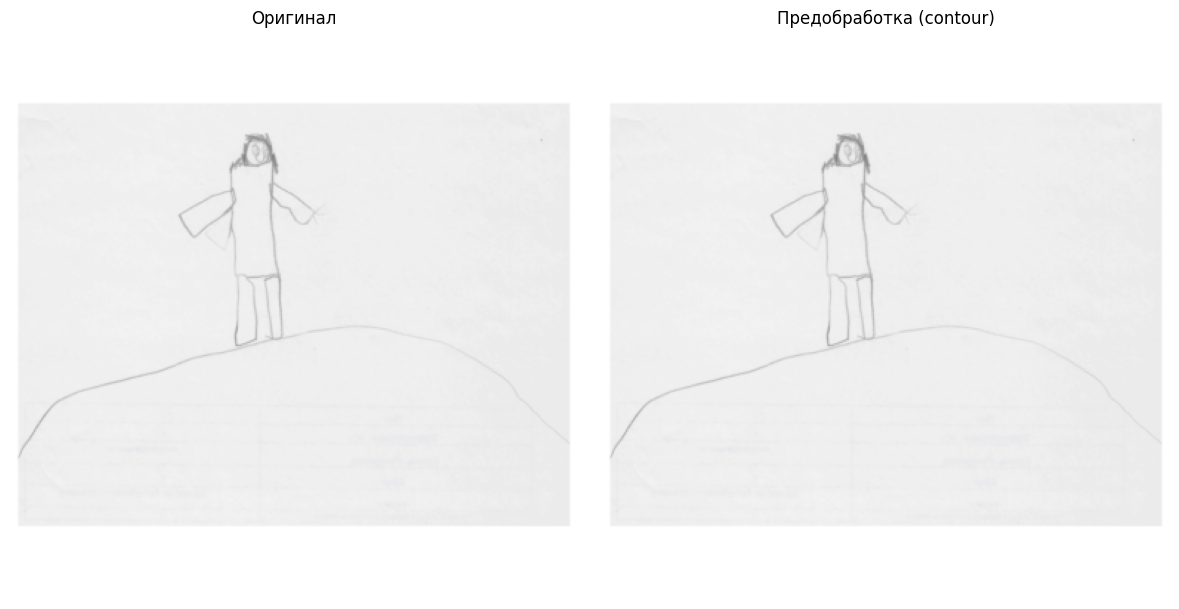


ТОП-10 АКТИВНЫХ:
  голова | отсутствует/6                                       → 1
  детализированность                                           → 'Низкая/2'
  зубы                                                         → 'Отсутствуют/1'
  изображение в рамке                                          → 'нет/2'
  изображение персонажа                                        → 'нет/2'
  кисть | отсутствует/6                                        → 1
  нажим | без особенностей/1                                   → 1
  одежда | отсутствует, тело изображено условно/4              → 1
  особенности линии | "промахивающиеся"/6                      → 1
  особенности линии | без особенностей/1                       → 1
  ... и ещё 16

ПСИХОЛОГИЧЕСКИЙ ПОРТРЕТ ПО РИСУНКУ ЧЕЛОВЕКА

Портрет составлен на основе автоматического анализа рисунка
и интерпретаций А.Л. Венгера.

Распознано особенностей рисунка: 30
Активных психологических черт: 12 (значимых, ≥2: 7)

------------------------------------

In [13]:
import matplotlib.pyplot as plt

TEST_IMAGE_PATH = None
TEST_CODE = None

PORTRAITS_DIR = Path('/content/portraits')
PORTRAITS_DIR.mkdir(parents=True, exist_ok=True)

if TEST_IMAGE_PATH is None:
    TEST_CODE = list(records_by_code.keys())[0]
    TEST_IMAGE_PATH = available_images[normalize(TEST_CODE)]
    print('using:', TEST_CODE)

print('img:', TEST_IMAGE_PATH)

original_pil = Image.open(TEST_IMAGE_PATH).convert('RGB')
cropped_pil, feats, src = crop_and_features(original_pil)

preds, _ = predict_image(TEST_IMAGE_PATH, code=TEST_CODE)
trait_support, evidence = derive_traits(preds, crit_json)
portrait = render_portrait(trait_support, evidence, crit_json)

out_path = PORTRAITS_DIR / 'portrait_demo.txt'
out_path.write_text(portrait, encoding='utf-8')

active_preds = [(c, p) for c, p in preds.items() if p not in (0, None, '', '0')]
print('bbox:', src, '| active:', len(active_preds), '/', len(preds), '| traits:', len(trait_support))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(original_pil); axes[0].set_title('Оригинал'); axes[0].axis('off')
axes[1].imshow(cropped_pil);  axes[1].set_title(f'Предобработка ({src})'); axes[1].axis('off')
plt.tight_layout(); plt.show()

print('\n' + '=' * 70)
print('ТОП-10 АКТИВНЫХ:')
print('=' * 70)
for c, p in active_preds[:10]:
    print(f'  {c[:60]:60s} → {p!r}')
if len(active_preds) > 10:
    print(f'  ... и ещё {len(active_preds) - 10}')

print('\n' + portrait)
print('saved to:', out_path)